## Import libraries

In [1]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import pandas as pd

from scipy.optimize import curve_fit, least_squares

from Fit_S11_Resonance import Fit_S11_Resonance

## Theoretical calculation of $S_{11}$

In [2]:
def compute_S11(freq_r: float, # Resonance frequency
                Q_tot: float, # Total quality factor
                Q_c: float, # Coupling quality factor
                tau: float, # Electric delay
                phi: float, # Impedance mismatch
                alpha: float, # Global phase
                a: float, # Global amplitude
                nb_points = 5000):
    
    # Compute parameters
    omega_r = 2 * np.pi * (freq_r * 1e9)
    kappa_tot = omega_r / Q_tot
    kappa_c = omega_r / Q_c
    kappa_i = kappa_tot - kappa_c
    
    # Compute frequency span
    bandwidth = (20 * kappa_tot / (2 * np.pi)) * 1e-9
    freq = np.linspace(freq_r - (bandwidth / 2), freq_r + (bandwidth / 2), nb_points)
    omega = 2 * np.pi * (freq * 1e9)

    delta_omega = omega - omega_r
    delta_freq = freq - freq_r
    delta_freq_MHz = delta_freq * 1e3
    
    # Compute S11
    S11_ideal = 1 - ( (kappa_c * np.exp(1j*phi) ) / (kappa_tot / 2 + 1j * delta_omega))
    
    S11 = a * np.exp(1j* alpha) * np.exp(-1j * omega * tau) * S11_ideal
    
    S11_dB = 20 * np.log10(np.abs(S11))
    S11_phase_deg = np.rad2deg(np.angle(S11))
    S11_real = S11.real
    S11_imag = S11.imag
    
    return freq, S11_dB, S11_phase_deg, S11_real, S11_imag

# Test with theoretical $S_{11}$

[Fit S11] READY!


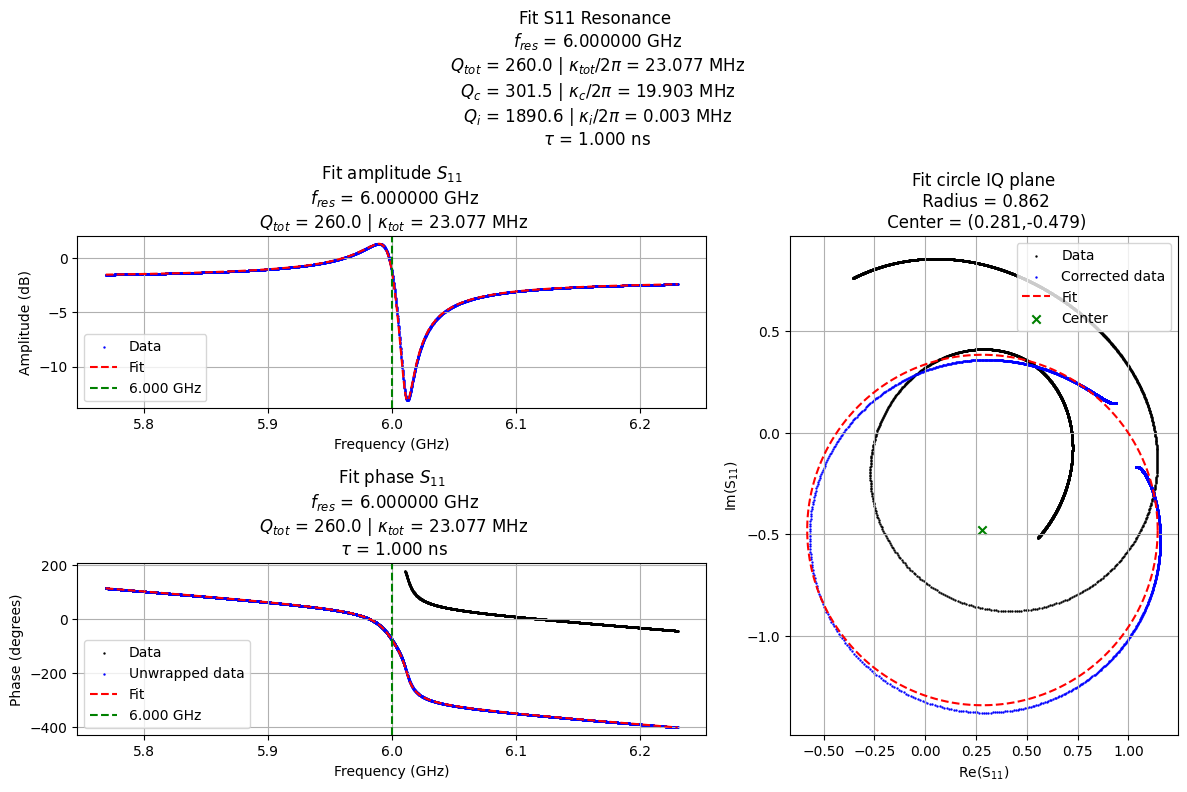

=== Resonance ===
 f_res = 6.000000 GHz

=== Quality factors ===
 Q_tot = 260.0
 Q_i = 1890.6
 Q_c = 301.5

=== Kappas ===
 'kappa' means 'kappa / 2pi'
 kappa_tot = 23.077 MHz
 kappa_i = 0.003 MHz
 kappa_c = 19.903 MHz

=== Electrical delay ===
 tau = 1.000 ns



In [3]:
freq, amp_dB, phase_deg, real, imag = compute_S11(freq_r = 6,
                                                  Q_tot = 260,
                                                  Q_c = 300,
                                                  tau = 1e-9,
                                                  phi = np.pi/5,
                                                  alpha = np.pi/5,
                                                  a = 0.8,
                                                  nb_points = 5000)

theory_data = Fit_S11_Resonance(freq = freq,
                                amp_dB = amp_dB,
                                phase_deg = phase_deg,
                                real = real,
                                imag = imag)

theory_data.fit_S11_signal()

theory_data.plot_all()

theory_data.print_results()

# Test with real data $S_{11}$

In [4]:
def extract_blocks(filename: str, lines_per_block: int):
    blocks = []          # will hold up to 3 lists of raw text lines
    current_block = None

    with open(filename, "r") as fh:
        for line in fh:
            line = line.strip()
            if line == "BEGIN":
                current_block = []
            elif line == "END":
                if current_block is not None:
                    blocks.append(current_block)
                    current_block = None
            elif current_block is not None and line:
                current_block.append(line)

    if len(blocks) != 3:
        raise ValueError(
            f"Expected 3 data blocks delimited by BEGIN/END, found {len(blocks)}."
        )

    def parse_block(block_lines, expected_cols):
        """Convert a list of CSV text lines into a 2-D numpy array."""
        rows = []
        for line in block_lines:
            parts = line.split(",")
            if len(parts) < expected_cols:
                continue                  # skip malformed rows silently
            rows.append([float(p) for p in parts[:expected_cols]])
        arr = np.array(rows, dtype=np.float64)
        if len(arr) != lines_per_block:
            print(
                f"  Warning: block has {len(arr)} rows, expected {lines_per_block}.",
                file=sys.stderr,
            )
        return arr

    block1 = parse_block(blocks[0], 2)   # freq, amp
    block2 = parse_block(blocks[1], 2)   # freq, phase
    block3 = parse_block(blocks[2], 3)   # freq, real, imag

    frequency = block1[:, 0]
    amp       = block1[:, 1]
    phase     = block2[:, 1]
    real      = block3[:, 1]
    imag      = block3[:, 2]

    return frequency, amp, phase, real, imag

[Fit S11] READY!


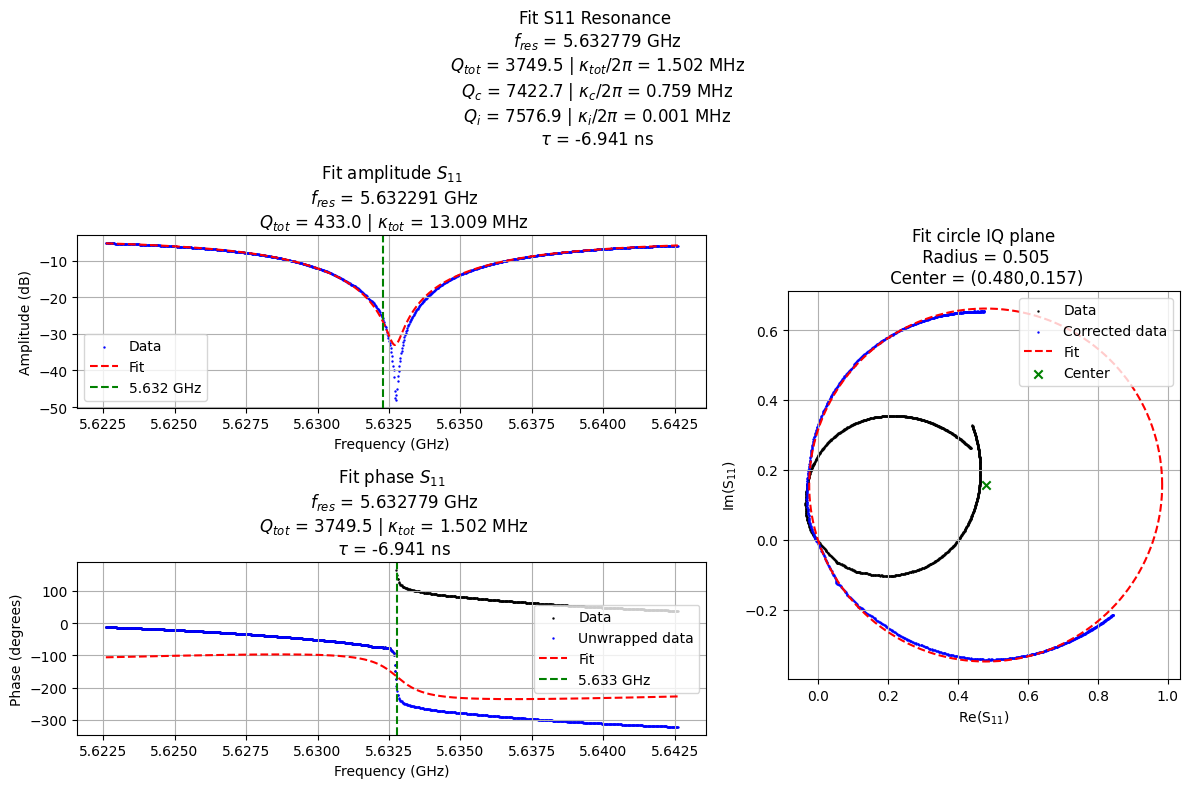

In [5]:
freq, amp_dB, phase_deg, real, imag = extract_blocks('../Data_Old_Cavity/TEST.csv', 1001)
freq = freq*1e-9

test_data = Fit_S11_Resonance(freq = freq,
                                amp_dB = amp_dB,
                                phase_deg = phase_deg,
                                real = real,
                                imag = imag)

test_data.fit_S11_signal()

test_data.plot_all()

[Fit S11] READY!


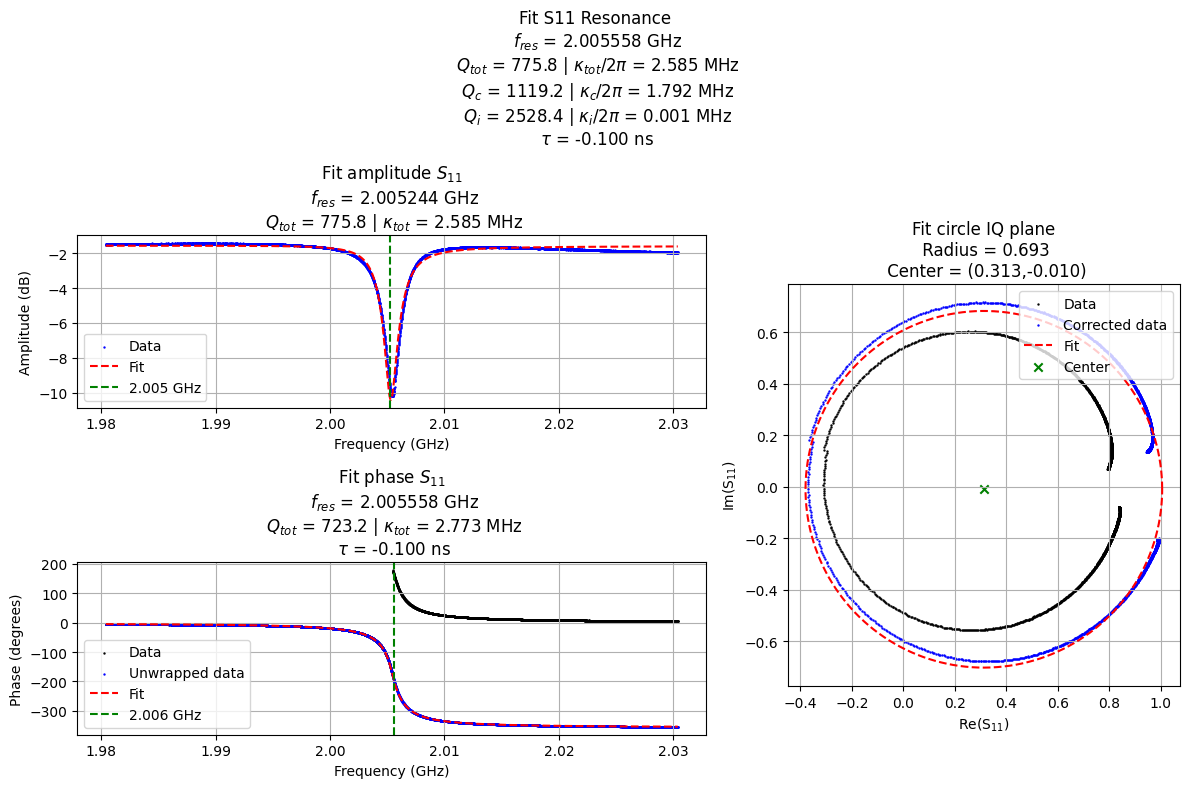

In [5]:
freq, amp_dB, phase_deg, real, imag = extract_blocks('../Data_Old_Cavity/OVERCOUPLED.csv', 5001)
freq = freq*1e-9

overcoupled_data = Fit_S11_Resonance(freq = freq,
                                amp_dB = amp_dB,
                                phase_deg = phase_deg,
                                real = real,
                                imag = imag)

overcoupled_data.fit_S11_signal()

overcoupled_data.plot_all()

[Fit S11] READY!


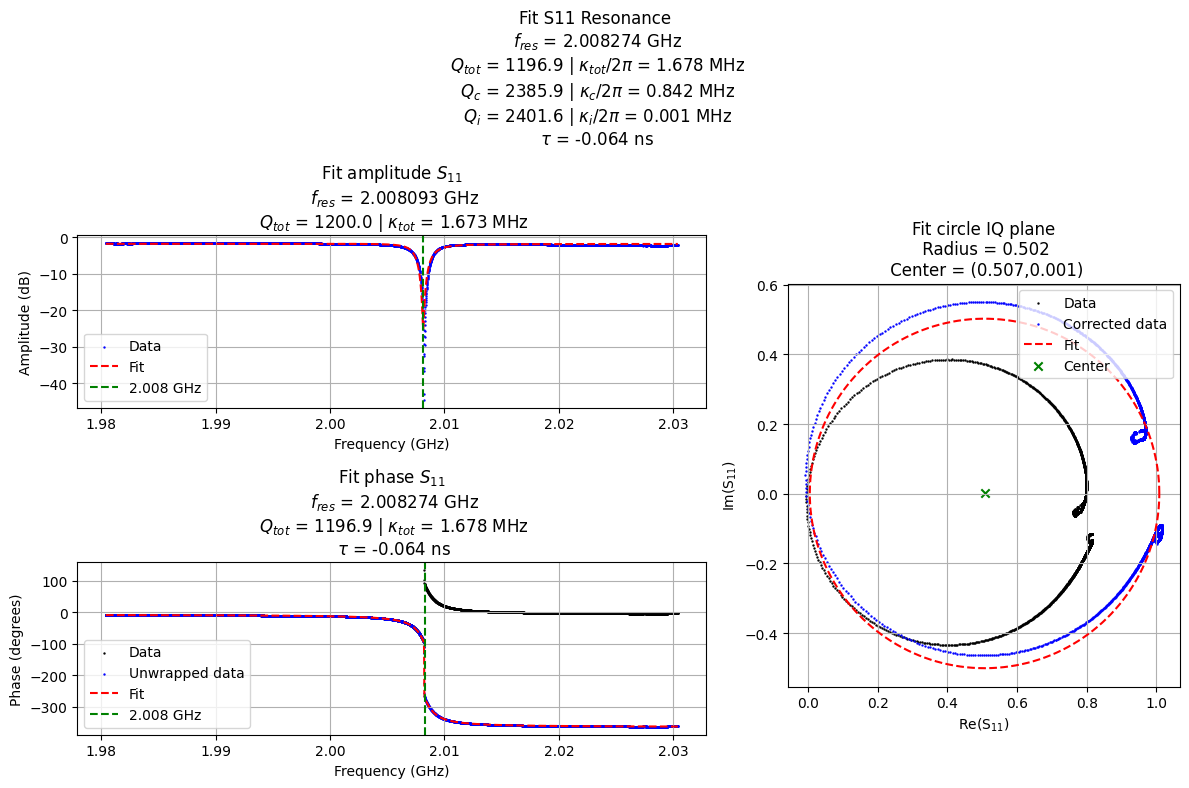

In [7]:
freq, amp_dB, phase_deg, real, imag = extract_blocks('../Data_Old_Cavity/CRITICALCOUPLING.csv', 5001)
freq = freq*1e-9

critical_data = Fit_S11_Resonance(freq = freq,
                                amp_dB = amp_dB,
                                phase_deg = phase_deg,
                                real = real,
                                imag = imag)

critical_data.fit_S11_signal()

critical_data.plot_all()

[Fit S11] READY!


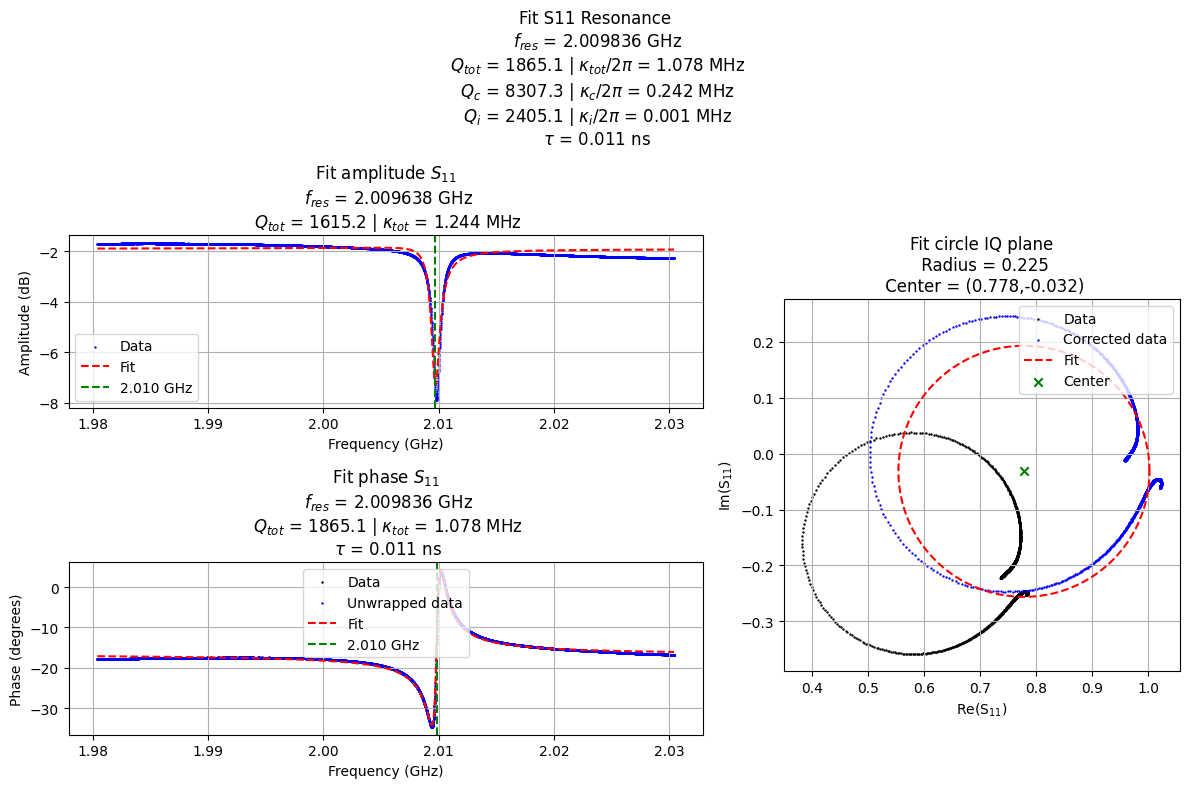

In [8]:
freq, amp_dB, phase_deg, real, imag = extract_blocks('../Data_Old_Cavity/UNDERCOUPLED.csv', 5001)
freq = freq*1e-9

undercoupled_data = Fit_S11_Resonance(freq = freq,
                                amp_dB = amp_dB,
                                phase_deg = phase_deg,
                                real = real,
                                imag = imag)

undercoupled_data.fit_S11_signal()

undercoupled_data.plot_all()

[Fit S11] READY!


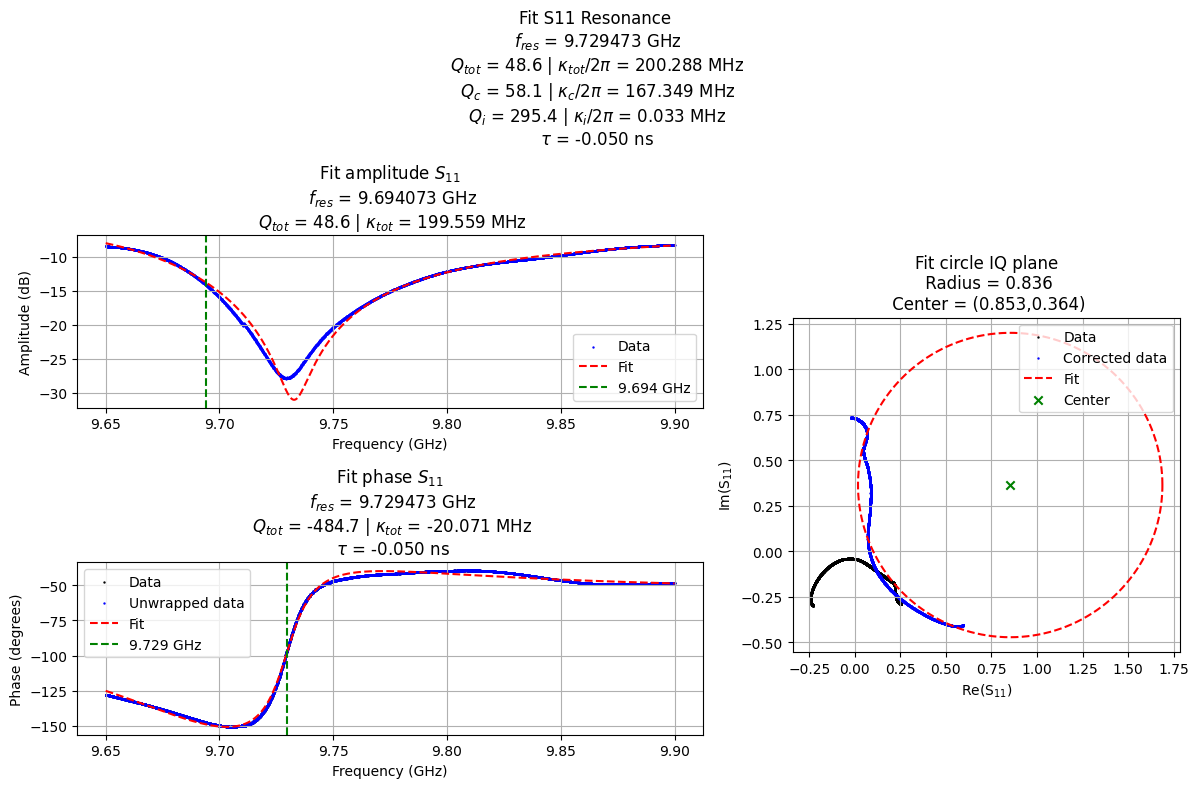

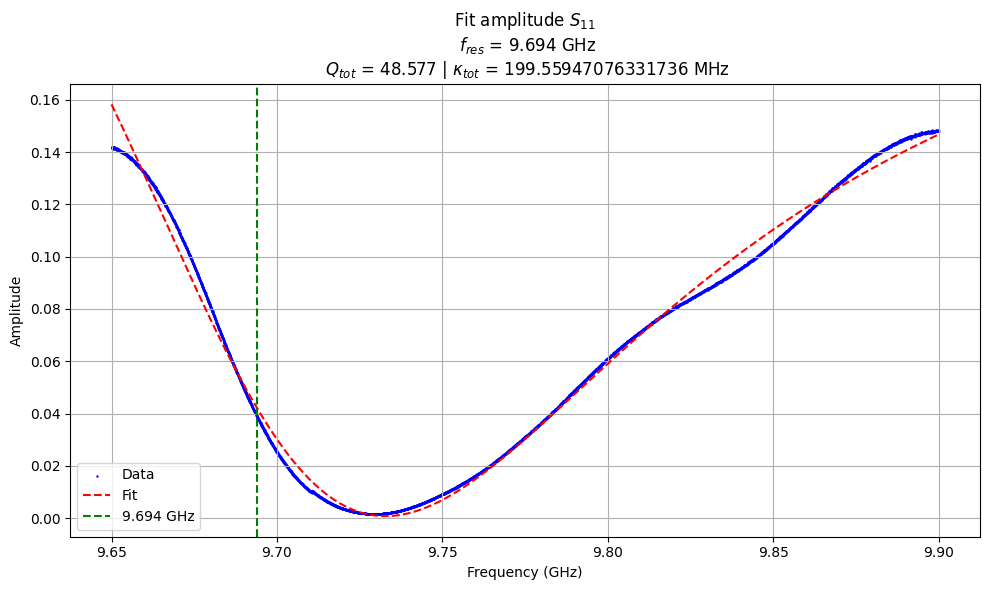

=== Resonance ===
 f_res = 9.729473 GHz

=== Quality factors ===
 Q_tot = 48.6
 Q_i = 295.4
 Q_c = 58.1

=== Kappas ===
 'kappa' means 'kappa / 2pi'
 kappa_tot = 200.288 MHz
 kappa_i = 0.033 MHz
 kappa_c = 167.349 MHz

=== Electrical delay ===
 tau = -0.050 ns



In [8]:
freq, amp_dB, phase_deg, real, imag = extract_blocks('../Data_Old_Cavity/SL_MUG.csv', 5001)
freq = freq*1e-9

amp_dB = 10*np.log10(real**2 + imag**2)

SL_mug = Fit_S11_Resonance(freq = freq,
                                amp_dB = amp_dB,
                                phase_deg = phase_deg,
                                real = real,
                                imag = imag)

SL_mug.fit_S11_signal()

SL_mug.plot_all()

SL_mug.plot_fit_amplitude()

SL_mug.print_results()